# Routing with an Efficient Beam Search

In [1]:
from dataclasses import dataclass
from heapq import nsmallest
from pathlib import Path
from sys import getsizeof
from time import perf_counter
import math

import matplotlib.pyplot as plt
import osmnx as ox

# Cache Overpass responses as well as the finished GraphML network.
ox.settings.use_cache = True
ox.settings.cache_folder = "osmnx_cache"
ox.settings.requests_timeout = 180


## Download or load the street network


In [2]:
# Points are specified as (latitude, longitude).
origin_point = (40.7484, -73.9857)       # Empire State Building
destination_point = (40.7826, -73.9656)  # Central Park

# Center the query between the two POIs and add a buffer around both points.
center = (
    (origin_point[0] + destination_point[0]) / 2,
    (origin_point[1] + destination_point[1]) / 2,
)

def haversine_m(lat1, lon1, lat2, lon2):
    """Great-circle distance in metres."""
    radius = 6_371_009.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = (
        math.sin(dphi / 2) ** 2
        + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2) ** 2
    )
    return 2 * radius * math.asin(math.sqrt(a))

graph_radius = haversine_m(*origin_point, *destination_point) / 2 + 1_200
graph_file = Path("nyc_empire_central_park_drive.graphml")

if graph_file.exists():
    G = ox.load_graphml(graph_file)
    print(f"Loaded cached graph: {graph_file}")
else:
    G = ox.graph_from_point(
        center,
        dist=graph_radius,
        network_type="drive",
        simplify=True,
    )
    ox.save_graphml(G, graph_file)
    print(f"Downloaded and cached graph: {graph_file}")

origin_id = ox.distance.nearest_nodes(G, origin_point[1], origin_point[0])
destination_id = ox.distance.nearest_nodes(
    G, destination_point[1], destination_point[0]
)

print(f"Graph: {len(G.nodes):,} nodes and {len(G.edges):,} edges")
print(f"Origin node: {origin_id}; destination node: {destination_id}")


Loaded cached graph: nyc_empire_central_park_drive.graphml
Graph: 2,170 nodes and 4,549 edges
Origin node: 42446701; destination node: 42433927


## Efficient beam-search implementation


In [3]:
@dataclass
class BeamResult:
    route: list
    cost: float
    time: float
    explored: int
    peak_frontier_bytes: int
    beam_cost_history: list


def minimum_edge_length(G, u, v):
    """Return the shortest parallel edge from u to v, in metres."""
    edge_data = G.get_edge_data(u, v)
    return min(float(attributes.get("length", 1.0)) for attributes in edge_data.values())


def route_cost(G, route):
    """Calculate a route's actual network length in metres."""
    return sum(
        minimum_edge_length(G, u, v)
        for u, v in zip(route[:-1], route[1:])
    )


def node_heuristic(G, node, destination):
    """Straight-line lower bound from a node to the destination, in metres."""
    n = G.nodes[node]
    d = G.nodes[destination]
    return haversine_m(n["y"], n["x"], d["y"], d["x"])


def beam_search(G, origin, destination, beam_width=100, max_iterations=None):
    """Heuristic beam search over graph nodes.

    Each state is (estimated_total_cost, path_cost, current_node, path).
    Only the best `beam_width` states survive each iteration. Beam search is
    fast and memory-bounded, but it is not guaranteed to return the optimum.
    """
    if beam_width < 1:
        raise ValueError("beam_width must be at least 1")

    start = perf_counter()
    max_iterations = max_iterations or len(G)
    initial_h = node_heuristic(G, origin, destination)
    beam = [(initial_h, 0.0, origin, (origin,))]
    best_g = {origin: 0.0}
    explored = 0
    peak_frontier_bytes = getsizeof(beam)
    history = []

    for _ in range(max_iterations):
        candidates_by_node = {}
        completed = []

        for _, g, node, path in beam:
            explored += 1
            for neighbor in G.successors(node):
                if neighbor in path:  # prevent cycles
                    continue

                new_g = g + minimum_edge_length(G, node, neighbor)
                if new_g >= best_g.get(neighbor, math.inf):
                    continue

                new_path = path + (neighbor,)
                if neighbor == destination:
                    completed.append((new_g, new_path))
                else:
                    score = new_g + node_heuristic(G, neighbor, destination)
                    state = (score, new_g, neighbor, new_path)
                    previous = candidates_by_node.get(neighbor)
                    if previous is None or new_g < previous[1]:
                        candidates_by_node[neighbor] = state

        if completed:
            final_cost, final_path = min(completed, key=lambda item: item[0])
            return BeamResult(
                route=list(final_path),
                cost=final_cost,
                time=perf_counter() - start,
                explored=explored,
                peak_frontier_bytes=peak_frontier_bytes,
                beam_cost_history=history,
            )

        if not candidates_by_node:
            raise RuntimeError(
                "The beam became empty before reaching the destination. "
                "Try a larger beam_width or a larger graph area."
            )

        beam = nsmallest(
            beam_width,
            candidates_by_node.values(),
            key=lambda state: state[0],
        )
        for _, g, node, _ in beam:
            best_g[node] = g
        history.append([state[1] for state in beam])
        peak_frontier_bytes = max(
            peak_frontier_bytes,
            getsizeof(beam) + sum(getsizeof(state) + getsizeof(state[3]) for state in beam),
        )

    raise RuntimeError("Maximum number of beam-search iterations reached")


## Run and evaluate the search


In [4]:
solution = beam_search(
    G,
    origin_id,
    destination_id,
    beam_width=100,
)
route = solution.route

# Dijkstra provides the exact shortest-distance baseline.
exact_route = ox.routing.shortest_path(
    G,
    origin_id,
    destination_id,
    weight="length",
)
exact_cost = route_cost(G, exact_route)
gap = 100 * (solution.cost - exact_cost) / exact_cost

print(f"Beam-search cost: {solution.cost:,.1f} m")
print(f"Exact Dijkstra cost: {exact_cost:,.1f} m")
print(f"Optimality gap: {gap:.2f}%")
print(f"Beam-search time: {solution.time:.4f} s")
print(f"Explored states: {solution.explored:,}")
print(f"Peak frontier size (approx.): {solution.peak_frontier_bytes:,} bytes")


Beam-search cost: 5,201.5 m
Exact Dijkstra cost: 4,809.4 m
Optimality gap: 8.15%
Beam-search time: 0.0230 s
Explored states: 4,248
Peak frontier size (approx.): 53,720 bytes


## Plot convergence and the selected route


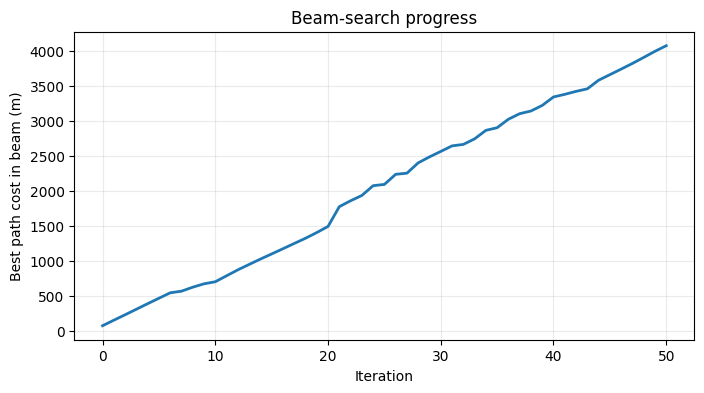

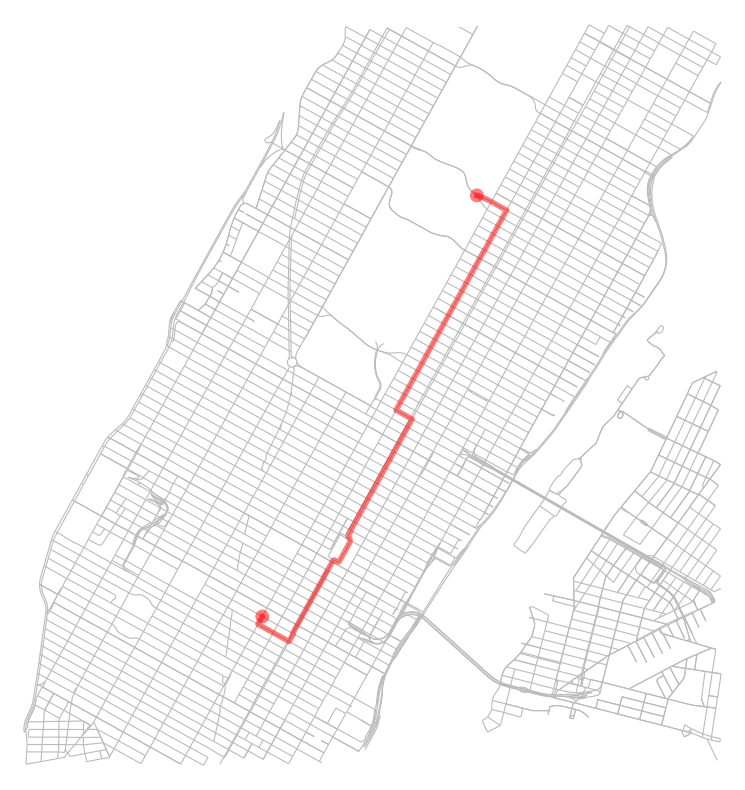

In [5]:
if solution.beam_cost_history:
    best_cost_per_iteration = [min(values) for values in solution.beam_cost_history]
    plt.figure(figsize=(8, 4))
    plt.plot(best_cost_per_iteration, linewidth=2)
    plt.xlabel("Iteration")
    plt.ylabel("Best path cost in beam (m)")
    plt.title("Beam-search progress")
    plt.grid(alpha=0.25)
    plt.show()

fig, ax = ox.plot_graph_route(
    G,
    route,
    route_color="red",
    route_linewidth=4,
    node_size=0,
    bgcolor="white",
    edge_color="#BBBBBB",
    edge_linewidth=0.8,
    figsize=(10, 10),
)


## Visualize the beam-search route on OpenStreetMap with an animated AntPath.

In [ ]:
import folium
from folium.plugins import AntPath


def route_coordinates(G, route):
    """Convert an OSMnx route to ordered (latitude, longitude) points."""
    coordinates = []

    for u, v in zip(route[:-1], route[1:]):
        # Select the shortest edge when parallel edges connect the same nodes.
        edge = min(
            G.get_edge_data(u, v).values(),
            key=lambda attributes: float(attributes.get("length", math.inf)),
        )
        geometry = edge.get("geometry")

        if geometry is None:
            segment = [
                (G.nodes[u]["y"], G.nodes[u]["x"]),
                (G.nodes[v]["y"], G.nodes[v]["x"]),
            ]
        else:
            segment = [(latitude, longitude) for longitude, latitude in geometry.coords]

            # Some stored edge geometries run opposite to the route direction.
            u_point = (G.nodes[u]["y"], G.nodes[u]["x"])
            first_distance = (segment[0][0] - u_point[0]) ** 2 + (
                segment[0][1] - u_point[1]
            ) ** 2
            last_distance = (segment[-1][0] - u_point[0]) ** 2 + (
                segment[-1][1] - u_point[1]
            ) ** 2
            if last_distance < first_distance:
                segment.reverse()

        if coordinates and coordinates[-1] == segment[0]:
            coordinates.extend(segment[1:])
        else:
            coordinates.extend(segment)

    return coordinates


animated_route = route_coordinates(G, route)
route_map = folium.Map(
    location=center,
    tiles="OpenStreetMap",
    zoom_start=14,
    control_scale=True,
)

AntPath(
    locations=animated_route,
    color="#D62728",
    pulse_color="#FFFFFF",
    weight=6,
    opacity=0.9,
    delay=700,
    dash_array=[10, 20],
    tooltip=f"Beam-search route: {solution.cost:,.1f} m",
).add_to(route_map)

folium.Marker(
    origin_point,
    tooltip="Origin: Empire State Building",
    popup="Empire State Building",
    icon=folium.Icon(color="green", icon="play"),
).add_to(route_map)

folium.Marker(
    destination_point,
    tooltip="Destination: Central Park",
    popup="Central Park",
    icon=folium.Icon(color="red", icon="flag"),
).add_to(route_map)

route_map.fit_bounds(animated_route)
route_map
